# Which part of a group's structure does a model use to multiply?

This is a reviewer's walkthrough. Read top to bottom. It runs in a few minutes,
offline, trains nothing, and touches no network or W&B. Every number is loaded
from a committed file under `results/`, or recomputed by importing the project's
own instruments from `src/group_algorithm_interp`, and nothing is transcribed
from prose.

### The question and the design

Train a small model to multiply in a finite group and it groks, snapping from
memorising the table to generalising. The question this study asks is which part
of the group's structure the trained model uses to do that. Any function on a
finite group can be written in the matrix entries of the group's irreducible
representations, so any model that computes the product correctly is using some
subset of that representation-theoretic information. The thesis is that the model
settles on a near-minimal faithful subset and computes the product from it,
without carrying the whole regular representation and without building the product
as a matrix multiplication over a shared index inside its neurons.

Prior readings differ across groups. On cyclic groups a model looks like it is
doing a discrete Fourier transform (Nanda et al., 2023). On S5 and S6 one reading
is a representation-theoretic circuit that embeds elements as
irreducible-representation matrices and decodes with characters (Chughtai, Chan &
Nanda, 2023), and another is a coset route that tracks which coset of a subgroup
each input lies in (Stander et al., 2024). A recent theorem shows that for a
related architecture each neuron aligns to a single irreducible representation
(He et al., 2026, preprint), though it does not say which representations a model
picks and it leaves the self-conjugate sector open, which is where the pairs below
do their work. Almost all the circuit-level evidence comes from one or two groups,
so the field cannot yet tell whether these readings genuinely conflict or a model
simply learns a different algorithm on different groups.

The design that pins this down is a controlled contrast. Two groups that share a
character table have the same character values but different
irreducible-representation matrices, so the character data cannot tell them apart.
A screen fixed before any training matches each pair on more than that, the
character table, the coset-template structure at every subgroup index, the
tensor-rank bounds, and the Frobenius-Schur indicators. A pair that survives is
one those readings must call identical. Train both members on the same seeds and
compare. Matching behaviour means the pairing worked as a control. A reproducible
within-pair difference would mean some invariant the pair holds fixed does not,
after all, pin the measurement, and it would say so without naming a single cause,
because the two members differ in several finer invariants at once.

The notebook walks the committed evidence: what the pairs share and where they
differ, the occupancy departure from the analytic null across the panel, one
shipped checkpoint run live through the occupancy, recruited-dimension and
matrix-product instruments, then the full thesis chain -- isotypic-block ablation,
recruited dimension against the minimal-faithful and regular-representation
anchors, the used-set audit as an honest limitation, the coset-quotient route as a
concrete instance, and the readout. Every number outside the live-checkpoint
section loads straight from a committed `results/*.json` file; nothing else here
trains or touches a checkpoint.


## Setup

Locate the repo root (so the notebook runs from anywhere), put `src` on the
path, disable W&B, and load the two campaign-level index files.

In [1]:
import os, sys, json
from pathlib import Path

os.environ["WANDB_MODE"] = "disabled"  # nothing here touches W&B, but be safe

# Find the repo root: walk up until we see src/group_algorithm_interp.
here = Path.cwd()
REPO = next(
    (p for p in [here, *here.parents] if (p / "src" / "group_algorithm_interp").is_dir()),
    None,
)
if REPO is None:  # running from notebooks/ with a shallow cwd
    REPO = Path.cwd().parent
assert (REPO / "src" / "group_algorithm_interp").is_dir(), REPO
sys.path.insert(0, str(REPO / "src"))
RESULTS = REPO / "results"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load(rel):
    return json.loads((RESULTS / rel).read_text())

canonical = load("canonical_runs.json")
verdict = load("grok_verdict.json")

gt = canonical["grok_totals_canonical"]
print(f"repo root: {REPO}")
print(f"distinct (group, width, epochs, seed) keys : {canonical['n_distinct_keys']:,}")
print(f"run directories on disk                    : {canonical['n_run_dirs']:,}")
print(f"canonical runs, grokked                    : {gt['grokked']:,}")
print(f"canonical runs, censored (never grokked)   : {gt['censored']:,}")
print(f"cells in the campaign                       : {len(verdict['cells'])}")

repo root: /Users/brooki/Developer/AI Safety Portfolio/group-algorithm-interpretability
distinct (group, width, epochs, seed) keys : 2,100
run directories on disk                    : 2,390
canonical runs, grokked                    : 1,544
canonical runs, censored (never grokked)   : 556
cells in the campaign                       : 42


## What the pairs share, and where they differ

The screen keeps only pairs that are identical in their character table, their
Frobenius-Schur indicators, and their tensor-rank bounds, and clean under a
coset-template test at every subgroup index. A character table fixes each
irreducible representation's character but not its real structure, whether its
matrices can be written with real entries or need quaternions. That real structure
is the Frobenius-Schur indicator, and D8 and Q8 share a character table yet differ
in it. Everything the pairing holds fixed is shared, so the pairing forces the two
members to look identical to any measurement that reads only those invariants. The
groups are still non-isomorphic, so they differ somewhere, and the table below
records where.

The table is built from data. The matched columns come from the committed
falsifier screen, and the distinguishing invariants come from the group-property
dataset. Two facts to read off it. The four order-64 pairs have identical
element-order distributions, so the power map plays no part in separating them, and
the difference sits in the Schur multiplier or the automorphism group, a different
invariant from one pair to the next. Only the order-27 pair differs in element
orders. A within-pair difference would therefore point to no single named cause,
because the distinguishing invariant is not even the same across pairs.

In [2]:
import statistics

C1_PAIRS = [
    ((27, 3), (27, 4)),
    ((64, 74), (64, 80)),
    ((64, 228), (64, 229)),
    ((64, 236), (64, 240)),
    ((64, 241), (64, 242)),
]

# Matched invariants: from the committed falsifier screen.
screen = load("falsifier_screen_results_full.json")
screen_idx = {(tuple(p["a"]), tuple(p["b"])): p for p in screen["pairs"]}

# Distinguishing invariants: one pass over the group-property dataset for the
# ten groups involved (element-order histogram, automorphism-group order,
# Schur-multiplier order, exponent).
wanted = {g for pair in C1_PAIRS for g in pair}
props = {}
with open(REPO / "data" / "group_properties_full.jsonl") as fh:
    for line in fh:
        d = json.loads(line)
        key = (d["order"], d["index"])
        if key in wanted:
            props[key] = d
        if len(props) == len(wanted):
            break

rows = []
for a, b in C1_PAIRS:
    p = screen_idx[(a, b)]
    same_orders = props[a]["element_order_histogram"] == props[b]["element_order_histogram"]
    diffs = []
    if props[a]["schur_multiplier_order"] != props[b]["schur_multiplier_order"]:
        diffs.append(f"Schur multiplier {props[a]['schur_multiplier_order']} vs {props[b]['schur_multiplier_order']}")
    if props[a]["aut_order"] != props[b]["aut_order"]:
        diffs.append(f"aut group {props[a]['aut_order']} vs {props[b]['aut_order']}")
    if not same_orders:
        diffs.append(f"element orders (exponent {props[a]['exponent']} vs {props[b]['exponent']})")
    rows.append({
        "pair": f"({a[0]},{a[1]})/({b[0]},{b[1]})",
        "char table equal": p["ct_equal"],
        "Frobenius-Schur identical": p["fs_strict_identical"],
        "same element orders": same_orders,
        "differs in": "; ".join(diffs),
    })

pairs_table = pd.DataFrame(rows)
pairs_table

,pair,char table equal,Frobenius-Schur identical,same element orders,differs in
0,"(27,3)/(27,4)",True,True,False,Schur multiplier 9 vs 1; aut group 432 vs 54; ...
1,"(64,74)/(64,80)",True,True,True,Schur multiplier 16 vs 8
2,"(64,228)/(64,229)",True,True,True,aut group 1024 vs 1536
3,"(64,236)/(64,240)",True,True,True,Schur multiplier 32 vs 16
4,"(64,241)/(64,242)",True,True,True,Schur multiplier 16 vs 64; aut group 1536 vs 9216


## The matched groups behave the same

For each pair the two members are identical in character table, Frobenius-Schur
indicators, and tensor-rank bounds, and clean under a coset-template screen, so a
clean control predicts no within-pair difference in behaviour. A tight interval
around zero bounds any difference the pairing could be hiding.

Two paired endpoints are measured at 50 paired seeds per group, the difference in
time-to-learn (censored seeds run to the epoch ceiling and carry no epoch) and the
difference in final unleaked accuracy. Both are read off the committed
`results/endpoints/pair_*.json` records. The (64,241)/(64,242) pair is measured at
its operative width 256 with the 400k-epoch ceiling, where all 50 seeds learn on
both members. The order-27 pair is measured at width 512, the width at which enough
seeds learn to support a paired comparison.

In [3]:
PAIRS = [
    ("pair_64_74__vs__64_80_w128",        "(64,74)/(64,80)",   "128",  "well-powered, 50/50"),
    ("pair_64_228__vs__64_229_w128",      "(64,228)/(64,229)", "128",  ""),
    ("pair_64_236__vs__64_240_w128",      "(64,236)/(64,240)", "128",  "heaviest censoring"),
    ("pair_27_3__vs__27_4_w512",          "(27,3)/(27,4)",     "512",  "staging probe"),
    ("pair_64_241__vs__64_242_w256_e400k", "(64,241)/(64,242)", "256",  "400k ceiling"),
]

rows = []
for fname, label, width, role in PAIRS:
    d = load(f"endpoints/{fname}.json")
    ep = d["epochs_to_grok_difference"]
    num = ep["numeric_both_grokked"]
    fu = d["final_unleaked_accuracy_difference"]
    lo, hi = num["bootstrap_ci_95"]
    flo, fhi = fu["bootstrap_ci_95"]
    rows.append({
        "pair": label,
        "width": width,
        "note": role,
        "both learned": f"{ep['n_both_grokked']}/50",
        "Δ epochs (mean)": round(num["mean_difference"], 1),
        "Δ epochs 95% CI": f"[{lo:,.0f}, {hi:,.0f}]",
        "Δ final-acc (mean)": round(fu["mean_difference"], 5),
        "Δ final-acc 95% CI": f"[{flo:+.4f}, {fhi:+.4f}]",
    })

c1_table = pd.DataFrame(rows)
c1_table

,pair,width,note,both learned,Δ epochs (mean),Δ epochs 95% CI,Δ final-acc (mean),Δ final-acc 95% CI
0,"(64,74)/(64,80)",128,"well-powered, 50/50",50/50,211.1,"[-891, 1,381]",0.00013,"[-0.0003, +0.0006]"
1,"(64,228)/(64,229)",128,,49/50,1512.2,"[-1,480, 4,759]",0.00105,"[-0.0001, +0.0028]"
2,"(64,236)/(64,240)",128,heaviest censoring,25/50,-5498.8,"[-13,038, 2,076]",-0.04687,"[-0.1285, +0.0321]"
3,"(27,3)/(27,4)",512,staging probe,20/50,4.3,"[-9,081, 9,062]",0.04250,"[-0.0458, +0.1288]"
4,"(64,241)/(64,242)",256,400k ceiling,50/50,2923.9,"[-8,210, 16,445]",-0.00078,"[-0.0016, -0.0002]"


Read the intervals against the scale. Grokking takes tens of thousands of epochs,
and final accuracy is a fraction in [0, 1]. Every time-to-learn interval straddles
zero. The staged and heavily-censored pairs have wide intervals, as expected given
how few seeds learned on both members. The pair with all 50 seeds learned on both
members, `(64,74)/(64,80)`, is the one to weight. Its time-to-learn difference is
bounded to roughly ±1,000 on a scale of tens of thousands, and its
final-accuracy difference to within ±0.0006.

One final-accuracy interval does exclude zero, on (64,241)/(64,242) at width 256,
−0.00078 [−0.00156, −0.00022], with both members at accuracy about
1.0. That is under one part in a thousand between two models that both essentially
solve the task, small enough to report and set aside.

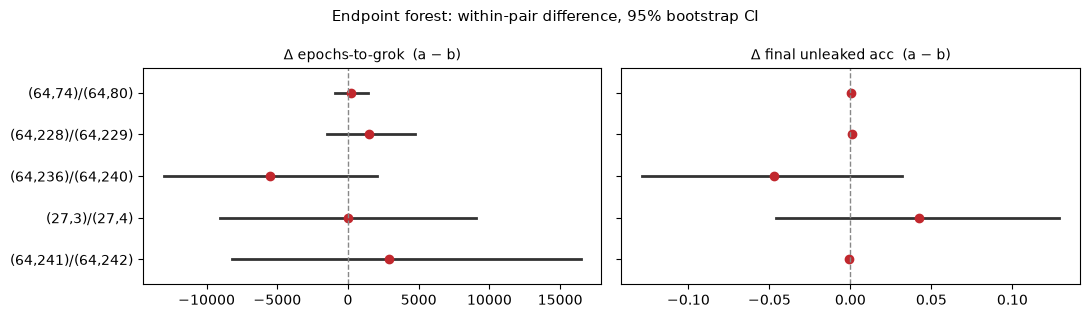

In [4]:
# Render the endpoint forest inline from the same JSON, so you see data -> figure.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
ypos = np.arange(len(PAIRS))[::-1]

ep_means, ep_cis, fu_means, fu_cis, labels = [], [], [], [], []
for fname, label, width, role in PAIRS:
    d = load(f"endpoints/{fname}.json")
    num = d["epochs_to_grok_difference"]["numeric_both_grokked"]
    fu = d["final_unleaked_accuracy_difference"]
    ep_means.append(num["mean_difference"]); ep_cis.append(num["bootstrap_ci_95"])
    fu_means.append(fu["mean_difference"]); fu_cis.append(fu["bootstrap_ci_95"])
    labels.append(label)

for ax, means, cis, title in [
    (axes[0], ep_means, ep_cis, "Δ epochs-to-grok  (a − b)"),
    (axes[1], fu_means, fu_cis, "Δ final unleaked acc  (a − b)"),
]:
    for y, m, (lo, hi) in zip(ypos, means, cis):
        ax.plot([lo, hi], [y, y], color="#333", lw=2)
        ax.plot(m, y, "o", color="#c1272d", ms=6)
    ax.axvline(0, color="#888", ls="--", lw=1)
    ax.set_yticks(ypos); ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.margins(y=0.15)

fig.suptitle("Endpoint forest: within-pair difference, 95% bootstrap CI", fontsize=11)
fig.tight_layout()
plt.show()

Every pair's within-pair difference, in time-to-learn (left) and final accuracy
(right), sits on the zero line within its 95% interval, so no pair separates
its two members.

### Occupancy: is the equality real, or just noise?

A behavioural match could still hide a difference in what the two models learn. So
the contrast also compares the occupancy vector, how the ensemble's neurons
distribute over the group's irreducible representations, measured as each model's
total-variation distance to its own group's analytic null and then paired within
the pair. Different readings predict different shapes for that vector, a roughly
uniform spread over the non-trivial representations under the Fourier reading, or
weight concentrated on the representations of the induced permutation representation
under the coset reading. He et al. (2026, preprint) leaves which representations win
open for non-abelian groups, so this contrast targets exactly the question that
theorem does not settle. If the two members learned genuinely equal representations,
the paired contrast sits on zero too.

In [5]:
occ = load("occupancy/c1_occupancy_contrast.json")
occ_rows = []
for p in occ["pairs"]:
    diff = p["differences"]["left_nontrivial"]
    lo, hi = diff["bootstrap_ci_95"]
    occ_rows.append({
        "pair": p["pair"],
        "tier": p["tier"],
        "n paired": p["n_paired"],
        "Δ TV-to-null (mean)": None if diff["mean"] is None else round(diff["mean"], 4),
        "95% CI": "n/a" if lo is None else f"[{lo:+.3f}, {hi:+.3f}]",
    })
pd.DataFrame(occ_rows)

,pair,tier,n paired,Δ TV-to-null (mean),95% CI
0,"(27,3)/(27,4) w256",C1 (pinned width; below floor — thin),0,NaN,n/a
1,"(64,74)/(64,80)",C1,50,-0.0042,"[-0.023, +0.014]"
2,"(64,228)/(64,229)",C1,49,0.0079,"[-0.008, +0.024]"
3,"(64,236)/(64,240)",C1,26,-0.0142,"[-0.031, +0.003]"
4,"(64,241)/(64,242) w128",C1 (pinned width; below floor — thin),4,-0.1020,"[-0.236, +0.046]"
5,"(216,106)/(216,107)",C4 tier-2,46,0.0039,"[-0.014, +0.023]"
6,"(64,60)/(64,65)",C4 tier-3,50,0.0018,"[-0.010, +0.013]"
7,"(54,10)/(54,11) w256",C1 embedding probe,33,0.0177,"[-0.016, +0.053]"
8,"(27,3)/(27,4) w512 (operative width; e60k ceil...",C1 (rescued; operative width),17,0.0143,"[-0.048, +0.072]"
9,"(64,241)/(64,242) w256 (operative width; e400k...",C1 (rescued; operative width),50,0.0037,"[-0.026, +0.032]"


In [6]:
# The zero contrast only means something because the thing differenced is real.
# Read each member's occupancy against the nontrivial-irrep floor (the statistic
# the contrast differences), not the full-table floor.
for g in ("64_74", "64_80"):
    occ = load(f"occupancy/occupancy_{g}_w128.json")["pooled"][0]["occupancy"]["left"]
    nt = occ["nontrivial"]["tv_over_floor"]
    ft = occ["full"]["tv_over_floor"]
    print(f"SmallGroup({g.replace('_', ',')}): occupancy sits {nt:.1f}x above the "
          f"nontrivial-irrep floor   (full-table statistic {ft:.1f}x)")

SmallGroup(64,74): occupancy sits 35.3x above the nontrivial-irrep floor   (full-table statistic 49.5x)
SmallGroup(64,80): occupancy sits 32.9x above the nontrivial-irrep floor   (full-table statistic 47.8x)


Every pair with enough paired seeds shows a mean near zero with an interval spanning
it, so the occupancy distributions match within noise. For the tightest pair,
(64,74)/(64,80), the difference is −0.004 [−0.023, +0.014] over 50 seeds.
The `(27,3)/(27,4)` width-256 row has `n paired = 0` and reports no estimate, because
that probe cell sits below the occupancy floor.

The zero is only meaningful because the thing being differenced is real. Each
member's occupancy sits about 35x and 33x above the non-trivial-representation floor
(the cell above), so both models have learned a definite distribution over
representations, and the difference between those two learned distributions is what
sits at zero. That is what a clean control should show. A contrast at fixed
character table cannot say which subset a model uses on its own. It confirms that
the pairing pins the measurement, so any later instrument that reads a real
within-pair difference is reading something the character table does not fix.

### Occupancy departure from the analytic null, across the panel

Zoom out from the pair contrast above to the full measured panel. If a model
memorised the Cayley table instead of learning group structure, its neurons would
have no reason to prefer one isotypic block over another in proportion to the
block's own rank, so occupancy would sit near the analytic null (the share each
block would carry if the model's activation energy were spread in proportion to
block rank). A trained model departing sharply and consistently from that null,
far past the seed noise floor, rules out rote lookup; it does not by itself
separate the accounts that predict a non-uniform spread, including this thesis.


In [7]:
from group_algorithm_interp import stats as gai_stats

occ_files = sorted(
    p for p in (RESULTS / "occupancy").glob("occupancy_*.json")
    if p.name != "c1_occupancy_contrast.json"
)
dep_rows = []
for p in occ_files:
    d = json.loads(p.read_text())
    pooled = d["pooled"][0]
    grp, mdl = pooled["group"], pooled["model"]
    left, right = pooled["occupancy"]["left"]["full"], pooled["occupancy"]["right"]["full"]
    dep_rows.append({
        "cell": f"({grp['order']},{grp['index']}) w{mdl['d_model']}",
        "n_runs": pooled["n_runs"],
        "TV to null": (left["tv_to_null"] + right["tv_to_null"]) / 2,
        "x noise floor": (left["tv_over_floor"] + right["tv_over_floor"]) / 2,
    })

tv_vals = [r["TV to null"] for r in dep_rows]
floor_vals = [r["x noise floor"] for r in dep_rows]
tv_med = statistics.median(tv_vals)
tv_ci = gai_stats.bootstrap_ci(tv_vals, statistic=statistics.median)
print(f"{len(dep_rows)} measured cells")
print(f"median TV distance to the analytic null: {tv_med:.3f} [{tv_ci[0]:.3f}, {tv_ci[1]:.3f}]")
print(f"median departure over the seed noise floor: {statistics.median(floor_vals):.1f}x")

pd.DataFrame(dep_rows).sort_values("x noise floor", ascending=False).reset_index(drop=True)


26 measured cells
median TV distance to the analytic null: 0.558 [0.517, 0.609]
median departure over the seed noise floor: 44.0x


,cell,n_runs,TV to null,x noise floor
0,"(27,3) w512",32,0.460530,122.357236
1,"(27,4) w512",28,0.460356,114.411603
2,"(54,10) w256",43,0.528940,72.239761
3,"(54,11) w256",40,0.511200,67.337349
4,"(64,241) w256",50,0.537223,65.621697
5,"(64,242) w256",50,0.516764,63.122540
6,"(32,18) w256",49,0.474354,62.548099
7,"(32,20) w256",36,0.501453,56.675457
8,"(32,19) w256",19,0.526033,50.917636
9,"(64,74) w128",50,0.684992,49.545631


Every measured cell sits far from the rank-proportional null, tens of times its own
seed noise floor. That is expected under almost any account other than rote lookup,
including this thesis, so it works as a weak control confirming the measurement is
picking up real structure -- it does not by itself separate the accounts.


## A live checkpoint: the method running on trained weights

Every other number in this notebook loads straight from a committed `results/*.json`
record. This section is the exception: `notebooks/sample_runs/2026-07-20_143051_631691_core_db19e1/`
ships one real checkpoint (`final.pt`, seed 0, SmallGroup(64,228), width 128) so a
reviewer can watch the pipeline run rather than only read its output. This seed
grokked cleanly -- train, held-out and unleaked-held-out accuracy all 1.0 over the
full 60,000-epoch ceiling -- and (64,228) carries a degree-4 irreducible
representation, so it is a group where the matrix-product test in particular has
something to distinguish. The three cells below call the same instrument code that
produced every occupancy, recruited-dimension and matrix-product record under
`results/`, live, on this one checkpoint.


In [8]:
import torch
from group_algorithm_interp.instruments import report as instrument_report

SAMPLE_RUN = REPO / "notebooks" / "sample_runs" / "2026-07-20_143051_631691_core_db19e1"
assert (SAMPLE_RUN / "final.pt").is_file(), "shipped checkpoint missing -- see README"

live_occ = instrument_report.measure_run(SAMPLE_RUN, device=torch.device("cpu"))
print(f"status: {live_occ['status']}   group: {live_occ['group']['name']}   "
      f"checkpoint: {live_occ['checkpoint_selection']['checkpoint']}   "
      f"n_units: {live_occ['n_units']}")
lo = live_occ["occupancy"]["left"]["full"]
print(f"left embedding: TV-to-null {lo['tv_to_null']:.3f}, "
      f"{lo['tv_over_floor']:.1f}x this single run's own noise floor")


status: measured   group: SmallGroup(64,228)   checkpoint: final.pt   n_units: 256
left embedding: TV-to-null 0.792, 7.9x this single run's own noise floor


In [9]:
import yaml
from group_algorithm_interp.config import validate_config
from group_algorithm_interp.groups.catalog import resolve_group
from group_algorithm_interp.instruments.checkpoints import select_checkpoint
from group_algorithm_interp.instruments.recruited_dimension import measure_recruited_dimension
from group_algorithm_interp.training.trainer import build_model

sample_config = validate_config(yaml.safe_load((SAMPLE_RUN / "resolved_config.yaml").read_text()))
sample_selection = select_checkpoint(SAMPLE_RUN)
sample_group = resolve_group(sample_config.data.group)
sample_ckpt = torch.load(sample_selection.path, map_location="cpu", weights_only=False)
sample_model = build_model(sample_config, sample_group)
sample_model.load_state_dict(sample_ckpt["model_state_dict"])
print(f"loaded {sample_selection.path.name}, epoch {sample_selection.epoch}, "
      f"{sample_config.data.group.canonical_name}")

live_rd = measure_recruited_dimension(sample_model, sample_group, device=torch.device("cpu")).to_record()
th = live_rd["theoretical"]
print(f"recruited dimension: {live_rd['primary_recruited']:.2f}   "
      f"minimal-faithful anchor: {th['minimal_faithful_real_dimension']}   "
      f"regular rep |G|: {th['regular_rep']}")
print(f"closest anchor: {live_rd['discrimination']['closest']}   "
      f"ratio to minimal-faithful: {live_rd['discrimination']['ratios']['minimal_faithful_real']:.2f}   "
      f"ratio to |G|: {live_rd['discrimination']['ratios']['regular_rep']:.3f}")


loaded final.pt, epoch 59999, SmallGroup(64,228)


recruited dimension: 7.45   minimal-faithful anchor: 6   regular rep |G|: 64
closest anchor: minimal_faithful_real   ratio to minimal-faithful: 1.24   ratio to |G|: 0.116


In [10]:
from group_algorithm_interp.instruments.gcr_matmul import measure_gcr_matmul

live_mm = measure_gcr_matmul(sample_model, sample_group, device=torch.device("cpu"))
mm_rows = [{
    "irrep degree": fit.irrep_degree,
    "occupancy": round(fit.occupancy, 4),
    "matrix-product held-out FVE": round(fit.mp_fve_heldout, 4),
    "bilinear held-out FVE": round(fit.bilinear_fve_heldout, 4),
    "saturated ceiling FVE": round(fit.ab_fve_heldout, 4),
    "mp beats bilinear": fit.mp_favoured,
    "credits the mechanism": fit.credits_gcr,
} for fit in live_mm.fits]
pd.DataFrame(mm_rows).sort_values("irrep degree", ascending=False).reset_index(drop=True)


,irrep degree,occupancy,matrix-product held-out FVE,bilinear held-out FVE,saturated ceiling FVE,mp beats bilinear,credits the mechanism
0,4,0.0000,-0.0094,-0.1620,0.244,True,False
1,2,0.0000,-0.0032,-0.0097,0.244,True,False
2,2,0.0965,0.0137,0.0217,0.244,True,False
3,2,0.0000,-0.0029,-0.0101,0.244,True,False
4,2,0.0472,0.0054,0.0059,0.244,True,False
5,2,0.0000,-0.0056,-0.0187,0.244,True,False
6,2,0.1110,0.0039,0.0004,0.244,True,False


This checkpoint's own recruited dimension and matrix-product readings echo the
corpus findings developed below: the recruited dimension sits nearer the
minimal-faithful anchor than the full regular representation, and on the degree-4
irrep the matrix-product form beats the generic bilinear one without either
explaining positive held-out variance on its own, so the reading does not credit
the matrix-product mechanism here either -- one seed, not a corpus finding, but the
same pipeline that produced the panel below.


## Isotypic-block ablation: are the occupied blocks causally load-bearing?

Occupancy shows which blocks carry activation energy; it does not show whether
removing them changes what the model does. This instrument zeroes one isotypic
block at a time and reads the fraction of held-out predictions that flip, against a
rank- and norm-matched random subspace of the same block as a control. For each
measured cell, the block whose ablation does the most damage is read off directly
from `results/coset/iso_ablation_*.json` (no separate occupancy join).


In [11]:
iso_files = sorted((RESULTS / "coset").glob("iso_ablation_*.json"))
iso_rows = []
for p in iso_files:
    d = json.loads(p.read_text())
    if d["n_seeds_measured"] == 0:
        continue
    grp = d["cell"]
    best = max(
        b["modes"]["zero"]["flip_fraction_over_random"]["mean"]
        for b in d["blocks"] if not b["is_trivial"]
    )
    iso_rows.append({
        "cell": f"({grp['order']},{grp['index']}) w{grp['width']}",
        "n measured": d["n_seeds_measured"],
        "most-damaging block: flip-fraction over random": round(best, 3),
    })

iso_best = [r["most-damaging block: flip-fraction over random"] for r in iso_rows]
iso_med = statistics.median(iso_best)
iso_ci = gai_stats.bootstrap_ci(iso_best, statistic=statistics.median)
print(f"{len(iso_rows)} measured cells, {sum(1 for v in iso_best if v > 0)} positive")
print(f"median (most-damaging block's flip-fraction over random): "
      f"{iso_med:.3f} [{iso_ci[0]:.3f}, {iso_ci[1]:.3f}]")

pd.DataFrame(iso_rows).sort_values(
    "most-damaging block: flip-fraction over random", ascending=False
).reset_index(drop=True)


15 measured cells, 15 positive
median (most-damaging block's flip-fraction over random): 0.185 [0.155, 0.208]


,cell,n measured,most-damaging block: flip-fraction over random
0,"(48,28) w256",50,0.261
1,"(48,29) w128",36,0.225
2,"(32,19) w256",19,0.215
3,"(32,18) w256",49,0.208
4,"(48,28) w128",47,0.201
5,"(48,29) w256",47,0.198
6,"(54,10) w256",43,0.193
7,"(32,20) w128",22,0.185
8,"(54,11) w256",40,0.184
9,"(32,18) w128",33,0.183


Zeroing the block that matters most flips substantially more held-out predictions
than a matched random subspace of the same rank, in every measured cell. The
occupied blocks are not inert: at least one of them is doing real causal work over
and above what a same-sized random subspace would cost. Whether the occupied set as
a whole is *sufficient* on its own is a separate question, taken up next.


## Recruited dimension: the strong link

This instrument measures a principled effective dimension the trained model
recruits (a participation-ratio-style stable rank) and reads it as a ratio against
two anchors: the minimal faithful real dimension (the smallest total real dimension
of a set of irreducible representations whose direct sum is faithful -- the
mathematical core of the thesis) and the full regular representation, dimension
equal to the group order. A model recruiting a small multiple of the minimal
faithful dimension, far short of the whole regular representation, is the sharpest
quantitative form of the claim that a model settles on a near-minimal sufficient
subset rather than carrying everything it could.


In [12]:
rdim_files = sorted((RESULTS / "recruited_dimension").glob("recruited_dimension_*.json"))
rdim_rows, mf_means, reg_means = [], [], []
closest_mf = closest_reg = 0
for p in rdim_files:
    d = json.loads(p.read_text())
    s = d["summary"]
    mf = s["discrimination_ratios"]["minimal_faithful_real"]["mean"]
    reg = s["discrimination_ratios"]["regular_rep"]["mean"]
    mf_means.append(mf); reg_means.append(reg)
    closest_mf += s["closest_anchor_counts"].get("minimal_faithful_real", 0)
    closest_reg += s["closest_anchor_counts"].get("regular_rep", 0)
    rdim_rows.append({
        "cell": f"({s['order']},{s['index']}) w{s['width']}",
        "n": s["primary_recruited"]["n"],
        "recruited / minimal-faithful": round(mf, 2),
        "recruited / |G|": round(reg, 3),
        "closest anchor": max(s["closest_anchor_counts"], key=s["closest_anchor_counts"].get),
    })

mf_med = statistics.median(mf_means); mf_ci = gai_stats.bootstrap_ci(mf_means, statistic=statistics.median)
reg_med = statistics.median(reg_means); reg_ci = gai_stats.bootstrap_ci(reg_means, statistic=statistics.median)
n_total = closest_mf + closest_reg
print(f"{len(rdim_files)} measured cells, {n_total} seeds")
print(f"median recruited-dimension / minimal-faithful-real-dimension ratio: "
      f"{mf_med:.2f} [{mf_ci[0]:.2f}, {mf_ci[1]:.2f}]")
print(f"median recruited-dimension / |G| ratio: {reg_med:.3f} [{reg_ci[0]:.3f}, {reg_ci[1]:.3f}]")
print(f"closest to the minimal-faithful anchor in {closest_mf}/{n_total} seeds, "
      f"to the regular representation in {closest_reg}/{n_total}")

rdim_df = pd.DataFrame(rdim_rows).sort_values("recruited / minimal-faithful").reset_index(drop=True)
rdim_df


34 measured cells, 1225 seeds
median recruited-dimension / minimal-faithful-real-dimension ratio: 1.71 [1.39, 1.91]
median recruited-dimension / |G| ratio: 0.142 [0.125, 0.182]
closest to the minimal-faithful anchor in 1216/1225 seeds, to the regular representation in 9/1225


,cell,n,recruited / minimal-faithful,recruited / |G|,closest anchor
0,"(64,242) w128",7,0.98,0.123,minimal_faithful_real
1,"(64,80) w128",50,1.00,0.125,minimal_faithful_real
2,"(64,74) w128",50,1.01,0.127,minimal_faithful_real
3,"(64,241) w128",7,1.02,0.128,minimal_faithful_real
4,"(64,65) w128",49,1.11,0.104,minimal_faithful_real
5,"(64,60) w128",50,1.12,0.105,minimal_faithful_real
6,"(64,240) w128",34,1.13,0.141,minimal_faithful_real
7,"(64,236) w128",33,1.14,0.143,minimal_faithful_real
8,"(192,24) w128",49,1.34,0.056,minimal_faithful_real
9,"(64,228) w128",50,1.34,0.126,minimal_faithful_real


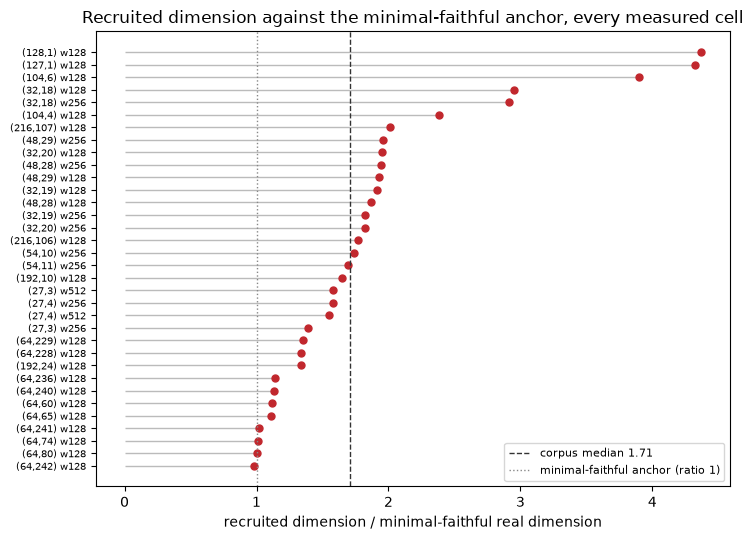

In [13]:
# Render the per-cell ratio to the minimal-faithful anchor, so you see data -> figure,
# alongside the live-checkpoint seed's own ratio for reference.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ypos = np.arange(len(rdim_df))
ax.hlines(ypos, 0, rdim_df["recruited / minimal-faithful"], color="#bbb", lw=1)
ax.plot(rdim_df["recruited / minimal-faithful"], ypos, "o", color="#c1272d", ms=5)
ax.axvline(mf_med, color="#333", ls="--", lw=1, label=f"corpus median {mf_med:.2f}")
ax.axvline(1.0, color="#888", ls=":", lw=1, label="minimal-faithful anchor (ratio 1)")
ax.set_yticks(ypos); ax.set_yticklabels(rdim_df["cell"], fontsize=7)
ax.set_xlabel("recruited dimension / minimal-faithful real dimension")
ax.set_title("Recruited dimension against the minimal-faithful anchor, every measured cell")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()


The median recruited model sits within a couple of multiples of its minimal
faithful real dimension and at a small fraction of the full regular representation,
and it sits closest to the minimal-faithful anchor in almost every measured seed.
The live-checkpoint seed above, recruited dimension 7.45 against a minimal-faithful
anchor of 6 (ratio 1.24) and a regular representation of 64, is on the low side of
this range but the same qualitative story: nearer the minimal-faithful anchor than
the whole group.


## The used-set audit: a limitation, not a success

Ablation above shows the occupied blocks are not inert. It does not show they are
*enough*. This instrument restricts the model to its occupied blocks -- ablating
everything outside them -- and reads how much held-out behaviour survives
(completeness), then ablates the used blocks one at a time to see how many are
individually necessary (minimality). Read this section as a limitation the thesis
has to carry, not as a further success: the restricted circuit is not a faithful
stand-in for the full model.


In [14]:
usa_files = sorted((RESULTS / "used_set_audit").glob("used_set_audit_*.json"))
usa_rows, retention_means, necessity_means = [], [], []
verdict_totals, n_seeds_total = {}, 0
for p in usa_files:
    d = json.loads(p.read_text())
    s = d["summary"]
    n_seeds_total += s["n_measured"]
    ret = s["completeness_accuracy_retention_fraction"]["mean"]["mean"]
    if ret is not None:
        retention_means.append(ret)
    nec_vals, used_vals = s["n_necessary_blocks"]["values"], s["n_used_blocks"]["values"]
    fracs = [n / u for n, u in zip(nec_vals, used_vals) if u > 0]
    if fracs:
        necessity_means.append(statistics.mean(fracs))
    for k, v in s["verdict_counts"].items():
        verdict_totals[k] = verdict_totals.get(k, 0) + v
    usa_rows.append({
        "cell": f"({s['order']},{s['index']}) w{s['width']}",
        "n": s["n_measured"],
        "retention (mean-ablation mode)": None if ret is None else round(ret, 3),
        "necessary / used blocks": None if not fracs else round(statistics.mean(fracs), 2),
    })

ret_med = statistics.median(retention_means)
ret_ci = gai_stats.bootstrap_ci(retention_means, statistic=statistics.median)
nec_med = statistics.median(necessity_means)
nec_ci = gai_stats.bootstrap_ci(necessity_means, statistic=statistics.median)
print(f"{len(usa_files)} measured cells, {n_seeds_total} seeds total")
print(f"median accuracy retention restricted to the occupied blocks: "
      f"{ret_med:.3f} [{ret_ci[0]:.3f}, {ret_ci[1]:.3f}]")
print(f"median fraction of used blocks individually necessary: "
      f"{nec_med:.3f} [{nec_ci[0]:.3f}, {nec_ci[1]:.3f}]")
print(f"verdict counts across every measured seed: {verdict_totals}")
n_sufficient_and_minimal = verdict_totals.get("sufficient_and_minimal_circuit", 0)
print(f"sufficient AND minimal: {n_sufficient_and_minimal}/{n_seeds_total} seeds")

pd.DataFrame(usa_rows).sort_values("retention (mean-ablation mode)").reset_index(drop=True)


31 measured cells, 1082 seeds total
median accuracy retention restricted to the occupied blocks: 0.097 [0.037, 0.104]
median fraction of used blocks individually necessary: 0.487 [0.413, 0.590]
verdict counts across every measured seed: {'neither_sufficient_nor_minimal': 711, 'minimal_but_not_sufficient': 160, 'empty_used_set': 205, 'sufficient_and_minimal_circuit': 5, 'sufficient_but_not_fully_minimal': 1}
sufficient AND minimal: 5/1082 seeds


,cell,n,retention (mean-ablation mode),necessary / used blocks
0,"(127,1) w128",49,0.007,NaN
1,"(128,2328) w128",50,0.007,NaN
2,"(128,1) w128",50,0.009,NaN
3,"(27,3) w512",31,0.024,NaN
4,"(104,6) w128",48,0.028,0.50
5,"(104,4) w128",48,0.031,0.58
6,"(48,29) w256",47,0.032,0.81
7,"(48,29) w128",33,0.033,0.82
8,"(54,11) w256",37,0.035,0.73
9,"(48,28) w128",46,0.036,0.76


Restricting a model to its occupied blocks collapses its behaviour: held-out
accuracy retention is a small fraction of the clean accuracy, and only about half
of the used blocks are individually necessary above the random-subspace control.
Almost no seed gives a circuit that is both sufficient and minimal. The occupied
blocks are disproportionately the necessary ones, but the model spreads causally
relevant structure well beyond the set this instrument flags -- an honest gap in
the thesis, not something the panel above should be read as papering over.


## The coset-quotient route: a concrete instance of the thesis

The coset route is the most recognisable single instance of the thesis: a model
tracking which coset of a normal subgroup an element lies in, and working out which
coset the product lands in. That is only a coherent algorithm when the subgroup is
normal, so the cosets themselves form the quotient group; the functions on the
group constant on each coset then form a subspace whose rank equals the quotient's
size. For each candidate quotient, this instrument restricts the model's shared
element embedding to that subspace (sufficiency: does coset prediction survive?)
and ablates it (necessity: does coset prediction drop?), both against a matched
random-subspace control.


In [15]:
cq_files = sorted((RESULTS / "coset_quotient").glob("coset_quotient_*.json"))
cq_rows = []
for p in cq_files:
    d = json.loads(p.read_text())
    s = d["summary"]
    best = max(s["quotients"], key=lambda q: q["coset_accuracy_over_random"]["mean"])
    o = best["coset_accuracy_over_random"]
    lo, hi = o["bootstrap_ci_95"]
    cq_rows.append({
        "cell": f"({s['order']},{s['index']}) w{s['width']}",
        "best quotient": f"subgroup {best['subgroup_index']} (rank {best['quotient_rank']})",
        "coset acc. over random (mean)": round(o["mean"], 3),
        "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
        "positive": lo > 0,
        "restricted acc. (sufficiency)": round(best["restricted_coset_accuracy"]["mean"], 3),
        "ablated acc. (necessity)": round(best["ablated_coset_accuracy"]["mean"], 3),
    })

cq_df = pd.DataFrame(cq_rows)
n_pos = int(cq_df["positive"].sum())
print(f"{len(cq_df)} measured cells; best quotient coordinate positive in {n_pos}/{len(cq_df)}")
vals = cq_df["coset acc. over random (mean)"]
print(f"range of best-quotient coset accuracy over random: {vals.min():.2f} to {vals.max():.2f}")
cq_df


10 measured cells; best quotient coordinate positive in 10/10
range of best-quotient coset accuracy over random: 0.36 to 0.79


,cell,best quotient,coset acc. over random (mean),95% CI,positive,restricted acc. (sufficiency),ablated acc. (necessity)
0,"(32,18) w128",subgroup 27 (rank 4),0.572,"[+0.499, +0.638]",True,0.843,0.320
1,"(32,18) w256",subgroup 27 (rank 4),0.578,"[+0.532, +0.623]",True,0.847,0.361
2,"(32,19) w128",subgroup 1 (rank 16),0.791,"[+0.780, +0.805]",True,0.984,0.092
3,"(32,19) w256",subgroup 1 (rank 16),0.772,"[+0.734, +0.797]",True,0.975,0.109
4,"(32,20) w128",subgroup 2 (rank 8),0.544,"[+0.420, +0.658]",True,0.710,0.194
5,"(32,20) w256",subgroup 1 (rank 16),0.589,"[+0.464, +0.699]",True,0.787,0.106
6,"(48,28) w128",subgroup 33 (rank 2),0.364,"[+0.298, +0.423]",True,0.879,0.675
7,"(48,28) w256",subgroup 19 (rank 6),0.521,"[+0.450, +0.590]",True,0.710,0.490
8,"(48,29) w128",subgroup 39 (rank 6),0.377,"[+0.297, +0.459]",True,0.560,0.418
9,"(48,29) w256",subgroup 1 (rank 24),0.447,"[+0.331, +0.560]",True,0.617,0.363


In [16]:
# D32 in detail, the concrete case the write-up walks through, at both widths.
print("D32 (32,18), best quotient (subgroup 27), both widths:")
for w in (128, 256):
    d = json.loads((RESULTS / "coset_quotient" / f"coset_quotient_32_18_w{w}.json").read_text())
    q = next(q for q in d["summary"]["quotients"] if q["subgroup_index"] == 27)
    r, a, o = q["restricted_coset_accuracy"], q["ablated_coset_accuracy"], q["coset_accuracy_over_random"]
    print(f"  w{w}: sufficiency (restricted) {r['mean']:.3f} {tuple(round(x,3) for x in r['bootstrap_ci_95'])}   "
          f"necessity (ablated) {a['mean']:.3f} {tuple(round(x,3) for x in a['bootstrap_ci_95'])}   "
          f"over random {o['mean']:.3f} {tuple(round(x,3) for x in o['bootstrap_ci_95'])}")
print()
print(json.loads((RESULTS / "coset_quotient" / "coset_quotient_32_18_w128.json").read_text())["summary"]["discrimination_note"])


D32 (32,18), best quotient (subgroup 27), both widths:
  w128: sufficiency (restricted) 0.843 (0.769, 0.91)   necessity (ablated) 0.320 (0.276, 0.369)   over random 0.572 (0.499, 0.638)
  w256: sufficiency (restricted) 0.847 (0.801, 0.891)   necessity (ablated) 0.361 (0.302, 0.425)   over random 0.578 (0.532, 0.623)

Decides coset-route ORGANISATION (does the model compute the output coset from a low-rank quotient coordinate), NOT coset-vs-GCR. On D32 the only clean quotient coordinate is the index-2 rotation parity, whose rank-2 subspace is exactly the trivial+sign linear-character blocks -- irreps the representation account also uses -- so a positive result here cannot be attributed against GCR (the carriers coincide; cf. the template-divergence degeneracy screen).


The best quotient coordinate beats its matched-random control on coset accuracy in
every measured cell, with intervals clear of zero. On D32 that positive reading
does not separate the coset account from the representation account: D32's only
clean quotient coordinate here draws on linear-character blocks the representation
account also uses, so the two carriers coincide on this group (the caveat printed
above, straight from the committed record). The coset route sits inside the thesis
as one of its concrete cases, not as a rival reading D32 could adjudicate.


## The readout: does the output stage need more than the character?

If the mechanism is not built as a matrix product in the neurons, the next question
is what the output stage reads. The thesis is that it reads the scalar character of
the product; the load-bearing measurement is whether keeping the full matrix
entries of the product, beyond just their trace, adds any held-out predictive power
over the character alone. A near-zero gain is the positive result. This is measured
on orders up to 64 so far; the panel is partial.


In [17]:
gr_files = sorted((RESULTS / "gcr_readout").glob("gcr_readout_*.json"))
gr_rows, gain_by_order = [], {}
for p in gr_files:
    d = json.loads(p.read_text())
    s = d["summary"]
    g = s["nested_comparison"]["full_vs_fourier_held_out_fve_gain"]["mean"]
    gr_rows.append({
        "cell": f"({s['order']},{s['index']}) w{s['width']}",
        "order": s["order"],
        "n": s["nested_comparison"]["full_vs_fourier_held_out_fve_gain"]["n"],
        "full-vs-character held-out FVE gain": round(g, 3),
    })
    gain_by_order.setdefault(s["order"], []).append(g)

le64 = [r["full-vs-character held-out FVE gain"] for r in gr_rows if r["order"] <= 64]
gain_med = statistics.median(le64)
gain_ci = gai_stats.bootstrap_ci(le64, statistic=statistics.median)
print(f"orders <= 64: {len(le64)} cells, median gain {gain_med:.3f} [{gain_ci[0]:.3f}, {gain_ci[1]:.3f}]")
print()
for order in sorted(o for o in gain_by_order if o <= 64):
    ov = gain_by_order[order]
    print(f"  order {order:>3}: median gain {statistics.median(ov):.3f}  (n cells={len(ov)})")

pd.DataFrame(gr_rows).sort_values(["order", "cell"]).reset_index(drop=True)


orders <= 64: 28 cells, median gain 0.067 [0.043, 0.180]

  order  27: median gain 0.055  (n cells=4)
  order  32: median gain 0.248  (n cells=6)
  order  48: median gain 0.478  (n cells=4)
  order  54: median gain 0.037  (n cells=2)
  order  64: median gain 0.037  (n cells=12)


,cell,order,n,full-vs-character held-out FVE gain
0,"(27,3) w256",27,6,0.046
1,"(27,3) w512",27,32,0.067
2,"(27,4) w256",27,3,0.048
3,"(27,4) w512",27,29,0.062
4,"(32,18) w128",32,36,0.236
5,"(32,18) w256",32,49,0.265
6,"(32,19) w128",32,5,0.193
7,"(32,19) w256",32,19,0.167
8,"(32,20) w128",32,25,0.260
9,"(32,20) w256",32,32,0.284


The gain is order-dependent. At orders 27, 54 and 64 it is a few points, consistent
with a character-only readout; at 32 and 48 it is substantially larger, so the
character-only reading is not clean across the board. Orders above 64 (192, 216)
are measured in `results/gcr_readout/` but outside the `<= 64` scope this section
reports on.


### Matrix-product versus bilinear: corpus status

The direct test of the representation account's mechanism -- whether the
post-nonlinearity activations form the shared-index matrix product `rho(a)rho(b) =
rho(ab)`, or whether a generic bilinear form fits at least as well -- is committed
for a handful of groups so far (counted below), plus the live (64,228) reading run
above (not yet in the committed corpus). The corpus table across every group whose
relevant irrep has degree at least 3 is still being computed.


In [18]:
mm_files = sorted((RESULTS / "gcr_matmul").glob("gcr_matmul_*.json"))
print(f"{len(mm_files)} committed matrix-product cells so far "
      "(plus the live (64,228) reading above, not yet committed)")
mm_corpus_rows = []
for p in mm_files:
    d = json.loads(p.read_text())
    agg = d["aggregate"]
    hi_deg = max(agg["irreps"], key=lambda ir: ir["irrep_degree"])
    mm_corpus_rows.append({
        "group": d["group"]["name"],
        "n seeds": agg["n_seeds_measured"],
        "highest irrep degree screened": hi_deg["irrep_degree"],
        "mp held-out FVE (mean)": round(hi_deg["mp_fve_heldout"]["mean"], 3),
        "bilinear held-out FVE (mean)": round(hi_deg["bilinear_fve_heldout"]["mean"], 3),
        "saturated ceiling FVE (mean)": round(hi_deg["ab_fve_heldout"]["mean"], 3),
    })
pd.DataFrame(mm_corpus_rows)


5 committed matrix-product cells so far (plus the live (64,228) reading above, not yet committed)


,group,n seeds,highest irrep degree screened,mp held-out FVE (mean),bilinear held-out FVE (mean),saturated ceiling FVE (mean)
0,"SmallGroup(192,10)",1,4,-0.003,-0.049,0.099
1,"SmallGroup(192,24)",1,4,-0.003,-0.051,0.091
2,"SmallGroup(216,106)",1,3,-0.000,-0.018,0.092
3,"SmallGroup(216,107)",1,3,-0.004,-0.026,0.083
4,"SmallGroup(27,3)",6,3,-0.029,-0.657,0.070


None of the committed readings, nor the live seed above, credits the matrix-product
mechanism over the generic bilinear form: both explain negative held-out variance
on the higher-degree irreps while the saturated ceiling explains a clearly positive
share, so there is product-dependent structure in the activations that neither
constrained form captures well. That is consistent with the thesis (the mechanism
is not credited to the neurons), but a handful of groups is not yet a corpus
finding.


### Character-versus-full-matrix readout characterisation: corpus status


In [19]:
rc_files = sorted((RESULTS / "readout_characterisation").glob("readout_characterisation_*.json"))
for p in rc_files:
    d = json.loads(p.read_text())
    s = d["summary"]
    g = s["gain"]["held_out_fve_gain_full_minus_character"]
    print(f"({s['order']},{s['index']}) w{s['width']}: n={g['n']} seeds, "
          f"full-minus-character held-out FVE gain {g['mean']:.3f} "
          f"{tuple(round(x, 3) for x in g['bootstrap_ci_95'])}")
print()
print(f"{len(rc_files)} of the panel's character-vs-full-matrix readout characterisations "
      "committed so far (small n; the run across the rest of the panel is still pending).")


(216,106) w128: n=5 seeds, full-minus-character held-out FVE gain 0.067 (0.034, 0.104)
(216,107) w128: n=4 seeds, full-minus-character held-out FVE gain 0.022 (0.019, 0.026)
(64,60) w128: n=5 seeds, full-minus-character held-out FVE gain 0.031 (0.014, 0.049)

3 of the panel's character-vs-full-matrix readout characterisations committed so far (small n; the run across the rest of the panel is still pending).


## Where to go next

- `docs/core-study.md` sets out the study design, the criterion-defined pair family,
  and what each reading predicts.
- `results/` holds every committed record shown above, the pinned falsifier screen
  (`falsifier_screen_results_full.json`) that defines the pair family, and the
  campaign index (`grok_verdict.json`, `canonical_runs.json`).
- `src/group_algorithm_interp/instruments/` holds the instruments. The cells above
  import them directly instead of reimplementing them, and the same directory holds
  the instruments the thesis turns on, among them `recruited_dimension.py` (effective
  dimension against the minimal faithful set), `gcr_matmul.py` (the matrix-product
  test), `readout_characterisation.py`, `coset_quotient.py`, and
  `used_set_audit.py` (the causal-sufficiency audit reported above as a limitation).
- `notebooks/sample_runs/2026-07-20_143051_631691_core_db19e1/` ships the one
  checkpoint this notebook runs live -- `final.pt`, `resolved_config.yaml`,
  `selection.json` and `manifest.yaml` -- alongside
  `data/group_artifacts/smallgroup_64_228.npz`, the group object it needs.
